# From a NumPy spectrum to Tetracorder results

This notebook is a complete, executed introduction to the `tetracorderpy` wrapper on PSC. It constructs reflectance from equations, sends it through the real **Tetracorder 6.00a5** container, examines the returned arrays, and then sends a 2 × 3 cube through one native batch run.

The curve is deliberately synthetic. It tests execution and data plumbing; its material matches are **not** scientific validation.

> This repository is a fork. The Python wrapper and this notebook are local integration work; they do not claim authorship of Tetracorder, Specpr, the expert system, or the USGS spectral libraries.

## Install on PSC

Consumers should install from the group-readable deployment checkout. That checkout and the shared SIF are maintained centrally, so a user does not clone the large library tree or rebuild the image.

```bash
uv add /ocean/projects/cis250251p/shared/repos/spectroscopy-tetracorder
uv run tetracorderpy setup --dry-run
```

The first command installs a normal, non-editable wheel into the consumer's uv environment. Development happens in a personal checkout; the shared checkout is updated by pull/fast-forward only.

## 1. Choose a native sensor profile

A profile connects an abstract spectrum to a Tetracorder dataset preset and a sensor response. The wrapper canonicalizes wavelengths and FWHM to micrometers. We pass the profile explicitly because the 1995 and 2024 AVIRIS presets share the same wavelength centers but have different native restart configurations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tetracorderpy import SpectralData, analyze, available_profiles, get_profile

profile = get_profile("aviris_1995")
wavelength = profile.wavelength
assert wavelength is not None

print("profile:", profile.name)
print("bands:", wavelength.size)
print("wavelength range (um):", float(wavelength.min()), "to", float(wavelength.max()))
print("exact FWHM available:", profile.fwhm is not None)
print("validation:", profile.metadata["validation"])

profile: aviris_1995
bands: 224
wavelength range (um): 0.37892981 to 2.49833569
exact FWHM available: True
validation: wavelength_and_fwhm


## 2. Construct a minimally plausible reflectance curve

The minimal scientific representation is a reflectance vector plus its wavelength coordinate. FWHM is also supplied here because it is known for this profile. The broad Gaussian dips mimic absorption features only well enough to exercise the workflow.

In [2]:
continuum = 0.47 + 0.07 * (wavelength - wavelength.min()) / np.ptp(wavelength)
spectrum = continuum.copy()
for center, depth, width in (
    (0.92, 0.11, 0.065),
    (2.20, 0.13, 0.035),
    (2.33, 0.055, 0.030),
):
    spectrum -= depth * np.exp(-0.5 * ((wavelength - center) / width) ** 2)

spectrum = np.clip(spectrum, 0.02, 0.98).astype(np.float32)
print("shape:", spectrum.shape, "dtype:", spectrum.dtype)
print("reflectance range:", float(spectrum.min()), "to", float(spectrum.max()))

shape: (224,) dtype: float32
reflectance range: 0.37786197662353516 to 0.5400000214576721


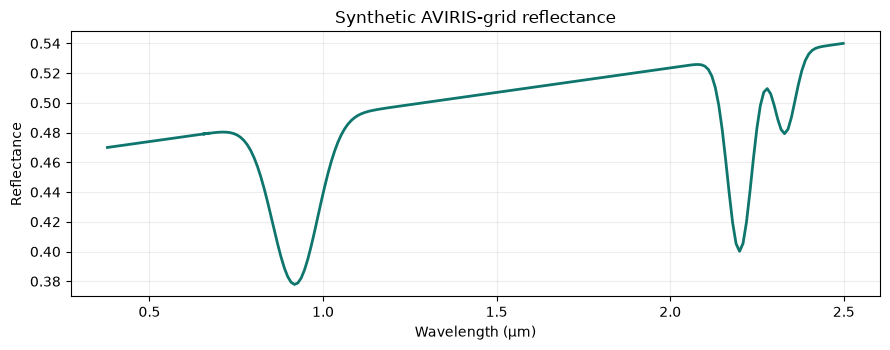

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(wavelength, spectrum, color="#0f766e", linewidth=2)
ax.set(
    title="Synthetic AVIRIS-grid reflectance",
    xlabel="Wavelength (µm)",
    ylabel="Reflectance",
)
ax.grid(alpha=0.22)
fig.tight_layout()

## 3. Run one spectrum

`analyze()` always uses the native **cube** executable. A one-dimensional spectrum becomes a 1 × 1 cube internally. By default its temporary input, logs, and maps are deleted after decoding; the returned object contains compact NumPy arrays.

In [4]:
from pathlib import Path

result = analyze(
    spectrum,
    wavelength=wavelength,
    fwhm=profile.fwhm,
    profile=profile,
    timeout=900.0,
)

print("backend:", result.backend_version)
print("result shape:", result.shape)
print("decision count:", len(result.decisions))
print("matched decisions:", int(result.matched.sum()))
print("native layout:", result.provenance["native_lines"], "x", result.provenance["native_samples"])
print("input spectra in native run:", result.provenance["input_spectra"])
print("SIF image:", Path(result.provenance["container"]).name)
print("SIF label:", result.provenance.get("container_label_version"))
print("native files retained:", result.artifacts_path)

backend: 6.00
result shape: (45,)
decision count: 45
matched decisions: 3
native layout: 1 x 1
input spectra in native run: 1
SIF image: tetracorder6_00a5.sif
SIF label: 6.00a5
native files retained: None


Each position on the final axis is one expert-system group or case. Use `matched` first; unmatched material IDs are `-1`. Fits and depths should be interpreted within Tetracorder's rules, not as generic probabilities.

In [5]:
matches = []
for index in np.flatnonzero(result.matched):
    decision = result.decisions[int(index)]
    material_id = int(result.material_id[index])
    matches.append(
        {
            "decision": f"{decision.kind} {decision.number}: {decision.name}",
            "material_id": material_id,
            "material": result.material_name(material_id),
            "fit": round(float(result.fit[index]), 6),
            "depth": round(float(result.depth[index]), 6),
            "fit_depth": round(float(result.fit_depth[index]), 6),
        }
    )

matches

[{'decision': 'group 1: group.1um',
  'material_id': 117,
  'material': 'fe2+fe3+_water_RTsludge',
  'fit': 0.847059,
  'depth': 0.207843,
  'fit_depth': 0.176471},
 {'decision': 'group 2: group.2um',
  'material_id': 196,
  'material': 'micagrp_muscovite-low-Al',
  'fit': 0.956863,
  'depth': 0.170588,
  'fit_depth': 0.162745},
 {'decision': 'group 4: group.1.5um-broad',
  'material_id': 385,
  'material': 'g4-fe2+generic_nrw.cummingtonite',
  'fit': 0.607843,
  'depth': 0.137255,
  'fit_depth': 0.084314}]

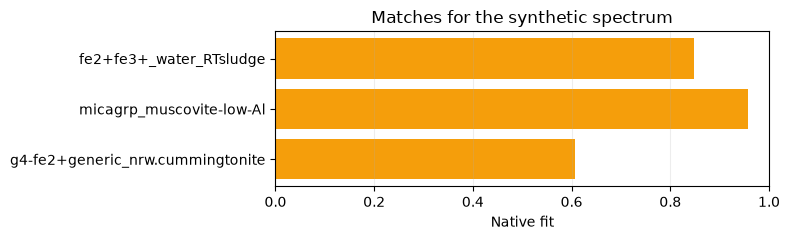

In [6]:
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.65 * len(matches))))
labels = [row["material"] for row in matches]
fits = [row["fit"] for row in matches]
ax.barh(labels, fits, color="#f59e0b")
ax.invert_yaxis()
ax.set(xlim=(0, 1), xlabel="Native fit", title="Matches for the synthetic spectrum")
ax.grid(axis="x", alpha=0.22)
fig.tight_layout()

## 4. Run a tensor as one native batch

Leading axes are sample axes; the final axis is spectral unless `spectral_axis=` says otherwise. Here six related spectra have shape `(2, 3, 224)`. The wrapper packs all six into one native 2 × 3 cube and launches one container process—not six processes.

In [7]:
offsets = np.linspace(-0.015, 0.015, 6, dtype=np.float32).reshape(2, 3, 1)
cube = np.clip(spectrum[None, None, :] + offsets, 0.02, 0.98)

batch = analyze(
    cube,
    wavelength=wavelength,
    fwhm=profile.fwhm,
    profile=profile,
    dims=("y", "x", "band"),
    coords={"scene": "synthetic tutorial"},
    metadata={"purpose": "execution demonstration"},
    timeout=900.0,
)

print("input shape:", cube.shape)
print("result shape:", batch.shape)
print("result dims:", batch.dims)
print("native layout:", batch.provenance["native_lines"], "x", batch.provenance["native_samples"])
print("spectra handled by this one run:", batch.provenance["input_spectra"])
print("matched decision cells:", int(batch.matched.sum()))
print("carried coordinates:", dict(batch.coords))
print("carried input metadata:", dict(batch.input_metadata))

input shape: (2, 3, 224)
result shape: (2, 3, 45)
result dims: ('y', 'x', 'decision')
native layout: 2 x 3
spectra handled by this one run: 6
matched decision cells: 18
carried coordinates: {'scene': 'synthetic tutorial'}
carried input metadata: {'purpose': 'execution demonstration'}


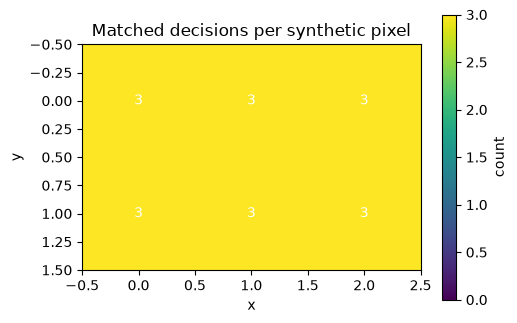

In [8]:
matches_per_pixel = batch.matched.sum(axis=-1)
fig, ax = plt.subplots(figsize=(5.2, 3.4))
image = ax.imshow(matches_per_pixel, cmap="viridis", vmin=0)
for y in range(matches_per_pixel.shape[0]):
    for x in range(matches_per_pixel.shape[1]):
        ax.text(x, y, int(matches_per_pixel[y, x]), ha="center", va="center", color="white")
ax.set(title="Matched decisions per synthetic pixel", xlabel="x", ylabel="y")
fig.colorbar(image, ax=ax, label="count")
fig.tight_layout()

## 5. What to adjust

Scientific inputs:

- `profile`: the native sensor/expert-system preset; it must match the wavelength response.
- `wavelength`, `fwhm`, and `wavelength_unit`: spectral calibration. Do not resample merely to force a match.
- `mask`: Boolean invalid cells or bands; NaN and infinity are also deleted.
- `spectral_axis`: where bands occur in the input tensor.

Execution controls:

- `timeout`: maximum seconds for the native process.
- `scratch_dir`: parent for temporary native files, useful for job-local PSC scratch. `TETRACORDER_TMPDIR` is the environment equivalent.
- `output_dir`: a new or empty directory that keeps raw native inputs, logs, and maps. Omit it for normal Python use.
- `container` and `runtime`: explicit overrides; normally shared discovery is preferable.

Temperature, pressure, geology overlays, native quick-look images, and arbitrary command strings are not exposed by this wrapper. Its tested path is reflectance classification through the 6.00 cube workflow.

## 6. Larger files and memory

`read_envi()` returns a storage-backed array when scaling does not force a copy. Temporary input packing is line-bounded, but native output maps and the five result tensors are materialized. For a very large scene, process spatial blocks and write each returned block into on-disk arrays. Do not launch one process per pixel.

```python
from tetracorderpy.formats import read_envi

data = read_envi("scene/reflectance")
for start in range(0, data.sample_shape[0], 128):
    stop = min(start + 128, data.sample_shape[0])
    block = SpectralData(
        data.values[start:stop],
        data.wavelength,
        fwhm=data.fwhm,
        mask=None if data.mask is None else data.mask[start:stop],
        dims=("y", "x", "band"),
    )
    block_result = analyze(block, profile="aviris_1995", scratch_dir="/path/to/job-scratch")
    # Store block_result arrays before continuing.
```

See the site pages on [large cubes](../guides/large-cubes.md), [results](../guides/results.md), [sampling](../concepts/sampling-and-profiles.md), and [PSC datasets](../data/psc-shared-datasets.md) for the scientific and storage boundaries.

## 7. Profile discovery is conservative

Exact calibration arrays are packaged for `aviris_1995`, `aviris_2024`, `emit_c`, and `aviris5_2025`. Other native 6.00 presets are available by explicit name with band-count validation when exact response tables are not yet mapped. Tetracorder 5.27 is not a supported backend.

In [9]:
names = available_profiles()
print("native 6.00 presets:", len(names))
print("selected examples:", [name for name in names if name in {"aviris_1995", "aviris_2024", "emit_c", "aviris5_2025", "prisma01a"}])

native 6.00 presets: 61
selected examples: ['aviris5_2025', 'aviris_1995', 'aviris_2024', 'emit_c', 'prisma01a']
